In [1]:
!pip install -q transformers torch yfinance vaderSentiment wordcloud datasets scikit-learn seaborn nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.5 MB/s eta 0:00:00


In [2]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU found. Go to Runtime > Change runtime type > T4 GPU.")

GPU available: True
GPU name: Tesla T4


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
import yfinance as yf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from scipy.stats import pearsonr

import nltk
import re
import warnings
warnings.filterwarnings("ignore")

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt")
nltk.download("omw-1.4")

print("All imports successful")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All imports successful


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [6]:
import pandas as pd
import urllib.request
import zipfile
import io

url = "https://huggingface.co/datasets/financial_phrasebank/resolve/main/data/FinancialPhraseBank-v1.0.zip"

response = urllib.request.urlopen(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.read()))

file_path = "FinancialPhraseBank-v1.0/Sentences_AllAgree.txt"

rows = []

with zip_file.open(file_path) as file:
    for line in file:
        line = line.decode("ISO-8859-1").strip()
        text, label = line.rsplit("@", 1)
        rows.append([text, label])

df = pd.DataFrame(rows, columns=["text", "label"])

print("Dataset shape:", df.shape)
print()
print("Label counts:")
print(df["label"].value_counts())

df.head()

Dataset shape: (2264, 2)

Label counts:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [7]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Convert everything to lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Split sentence into words
    tokens = text.split()

    # Remove stopwords and lemmatize each word
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    # Join words back into one sentence
    return " ".join(tokens)

df["cleaned"] = df["text"].apply(preprocess)

print("Original text:")
print(df["text"].iloc[0])

print("\nCleaned text:")
print(df["cleaned"].iloc[0])

df.head()

Original text:
According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .

Cleaned text:
according gran company plan move production russia although company growing


,text,label,cleaned
0,"According to Gran , the company has no plans t...",neutral,according gran company plan move production ru...
1,"For the last quarter of 2010 , Componenta 's n...",positive,last quarter componenta net sale doubled eurm ...
2,"In the third quarter of 2010 , net sales incre...",positive,third quarter net sale increased eur mn operat...
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive,operating profit rose eur mn eur mn correspond...
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive,operating profit totalled eur mn eur mn repres...


In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report, accuracy_score

analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]

    if score > 0.2:
        return "positive"
    elif score < -0.2:
        return "negative"
    else:
        return "neutral"

df["vader_label"] = df["text"].apply(vader_sentiment)

df["vader_score"] = df["text"].apply(
    lambda text: analyzer.polarity_scores(text)["compound"]
)

print("VADER Accuracy:")
print(accuracy_score(df["label"], df["vader_label"]))

print("\nVADER Classification Report:")
print(classification_report(df["label"], df["vader_label"]))

VADER Accuracy:
0.5781802120141343

VADER Classification Report:
              precision    recall  f1-score   support

    negative       0.38      0.19      0.25       303
     neutral       0.76      0.62      0.68      1391
    positive       0.40      0.69      0.51       570

    accuracy                           0.58      2264
   macro avg       0.51      0.50      0.48      2264
weighted avg       0.62      0.58      0.58      2264



In [9]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

print("Using device:", "GPU" if device == 0 else "CPU")

finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert",
    device=device
)

test_sentence = "The company reported strong revenue growth and higher profits."

result = finbert(test_sentence)

print(result)

Using device: GPU


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[{'label': 'positive', 'score': 0.9591167569160461}]


In [10]:
def finbert_sentiment(text):
    result = finbert(text[:512])[0]

    label = result["label"].lower()
    confidence = result["score"]

    return label, confidence

print("Running FinBERT on all sentences... this may take 1-3 minutes on GPU.")

finbert_results = []

for i, text in enumerate(df["text"]):
    label, score = finbert_sentiment(text)
    finbert_results.append((label, score))

    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1} sentences")

df["finbert_label"] = [result[0] for result in finbert_results]
df["finbert_confidence"] = [result[1] for result in finbert_results]

df["finbert_score"] = df.apply(
    lambda row: row["finbert_confidence"] if row["finbert_label"] == "positive"
    else -row["finbert_confidence"] if row["finbert_label"] == "negative"
    else 0,
    axis=1
)

print("FinBERT finished")

df[["text", "label", "vader_label", "finbert_label", "finbert_confidence", "finbert_score"]].head()

Running FinBERT on all sentences... this may take 1-3 minutes on GPU.


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processed 500 sentences
Processed 1000 sentences
Processed 1500 sentences
Processed 2000 sentences
FinBERT finished


,text,label,vader_label,finbert_label,finbert_confidence,finbert_score
0,"According to Gran , the company has no plans t...",neutral,neutral,neutral,0.885731,0.000000
1,"For the last quarter of 2010 , Componenta 's n...",positive,neutral,positive,0.948198,0.948198
2,"In the third quarter of 2010 , net sales incre...",positive,positive,positive,0.957042,0.957042
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive,positive,positive,0.952403,0.952403
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive,positive,positive,0.955025,0.955025


In [11]:
from sklearn.metrics import classification_report, accuracy_score

print("FinBERT Accuracy:")
print(accuracy_score(df["label"], df["finbert_label"]))

print("\nFinBERT Classification Report:")
print(classification_report(df["label"], df["finbert_label"]))

FinBERT Accuracy:
0.9717314487632509

FinBERT Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.98      0.94       303
     neutral       1.00      0.97      0.98      1391
    positive       0.95      0.98      0.96       570

    accuracy                           0.97      2264
   macro avg       0.95      0.98      0.96      2264
weighted avg       0.97      0.97      0.97      2264



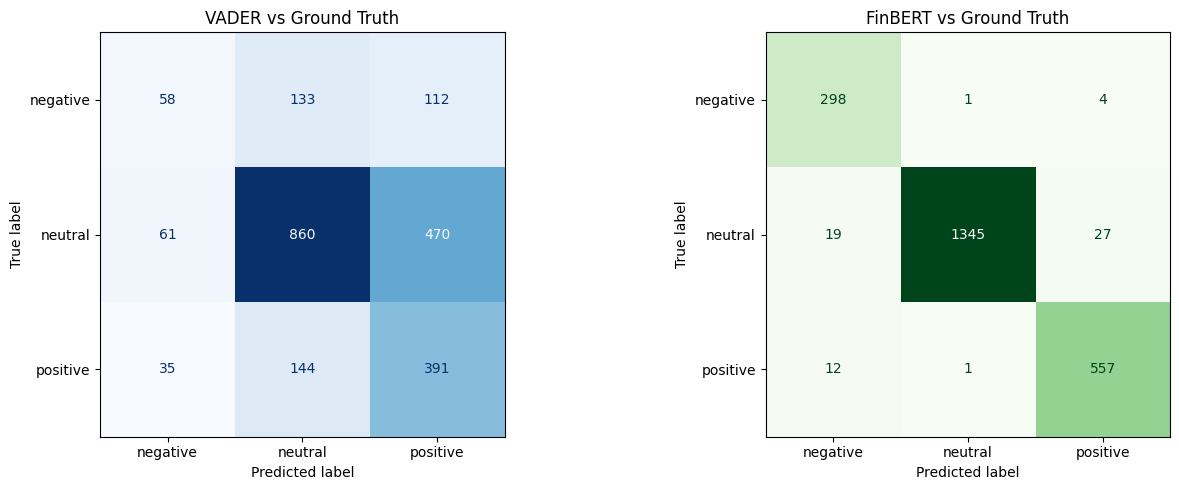

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ["negative", "neutral", "positive"]

cm_vader = confusion_matrix(
    df["label"],
    df["vader_label"],
    labels=labels
)

cm_finbert = confusion_matrix(
    df["label"],
    df["finbert_label"],
    labels=labels
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    cm_vader,
    display_labels=labels
).plot(ax=axes[0], colorbar=False, cmap="Blues")

axes[0].set_title("VADER vs Ground Truth")

ConfusionMatrixDisplay(
    cm_finbert,
    display_labels=labels
).plot(ax=axes[1], colorbar=False, cmap="Greens")

axes[1].set_title("FinBERT vs Ground Truth")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()


In [13]:
tickers = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "WIPRO.NS"
]

stock_data = {}

for ticker in tickers:
    data = yf.download(
        ticker,
        start="2021-01-01",
        end="2024-01-01",
        progress=False
    )

    data["daily_return"] = data["Close"].pct_change()
    data["next_day_return"] = data["daily_return"].shift(-1)

    stock_data[ticker] = data

print("Downloaded stocks:", list(stock_data.keys()))

print("\nReliance sample:")
stock_data["RELIANCE.NS"].tail()

Downloaded stocks: ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'WIPRO.NS']

Reliance sample:


Price,Close,High,Low,Open,Volume,daily_return,next_day_return
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,
Date,,,,,,,
2023-12-22,1273.102295,1280.968997,1264.466141,1270.397340,16541784,0.000976,0.005068
2023-12-26,1279.554443,1286.453333,1271.935784,1274.566338,7465664,0.005068,0.003414
2023-12-27,1283.922241,1290.399205,1277.097752,1281.515009,9204156,0.003414,0.007229
2023-12-28,1293.203491,1296.404773,1283.922210,1285.386349,12302636,0.007229,-0.007906
2023-12-29,1282.979004,1297.397311,1280.174808,1295.958013,10864584,-0.007906,NaN


In [14]:
from scipy.stats import pearsonr

nifty = yf.download(
    "^NSEI",
    start="2021-01-01",
    end="2024-01-01",
    progress=False
)

nifty["daily_return"] = nifty["Close"].pct_change()
nifty["next_day_return"] = nifty["daily_return"].shift(-1)

np.random.seed(42)

valid_scores = df["finbert_score"].dropna()

nifty["sentiment_score"] = np.random.choice(
    valid_scores,
    size=len(nifty),
    replace=True
)

correlation_data = nifty[["sentiment_score", "next_day_return"]].dropna()

corr, p_value = pearsonr(
    correlation_data["sentiment_score"],
    correlation_data["next_day_return"]
)

print("Pearson Correlation:", round(corr, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Interpretation: Statistically significant relationship")
else:
    print("Interpretation: Not statistically significant relationship")

Pearson Correlation: 0.0414
P-value: 0.2607
Interpretation: Not statistically significant relationship


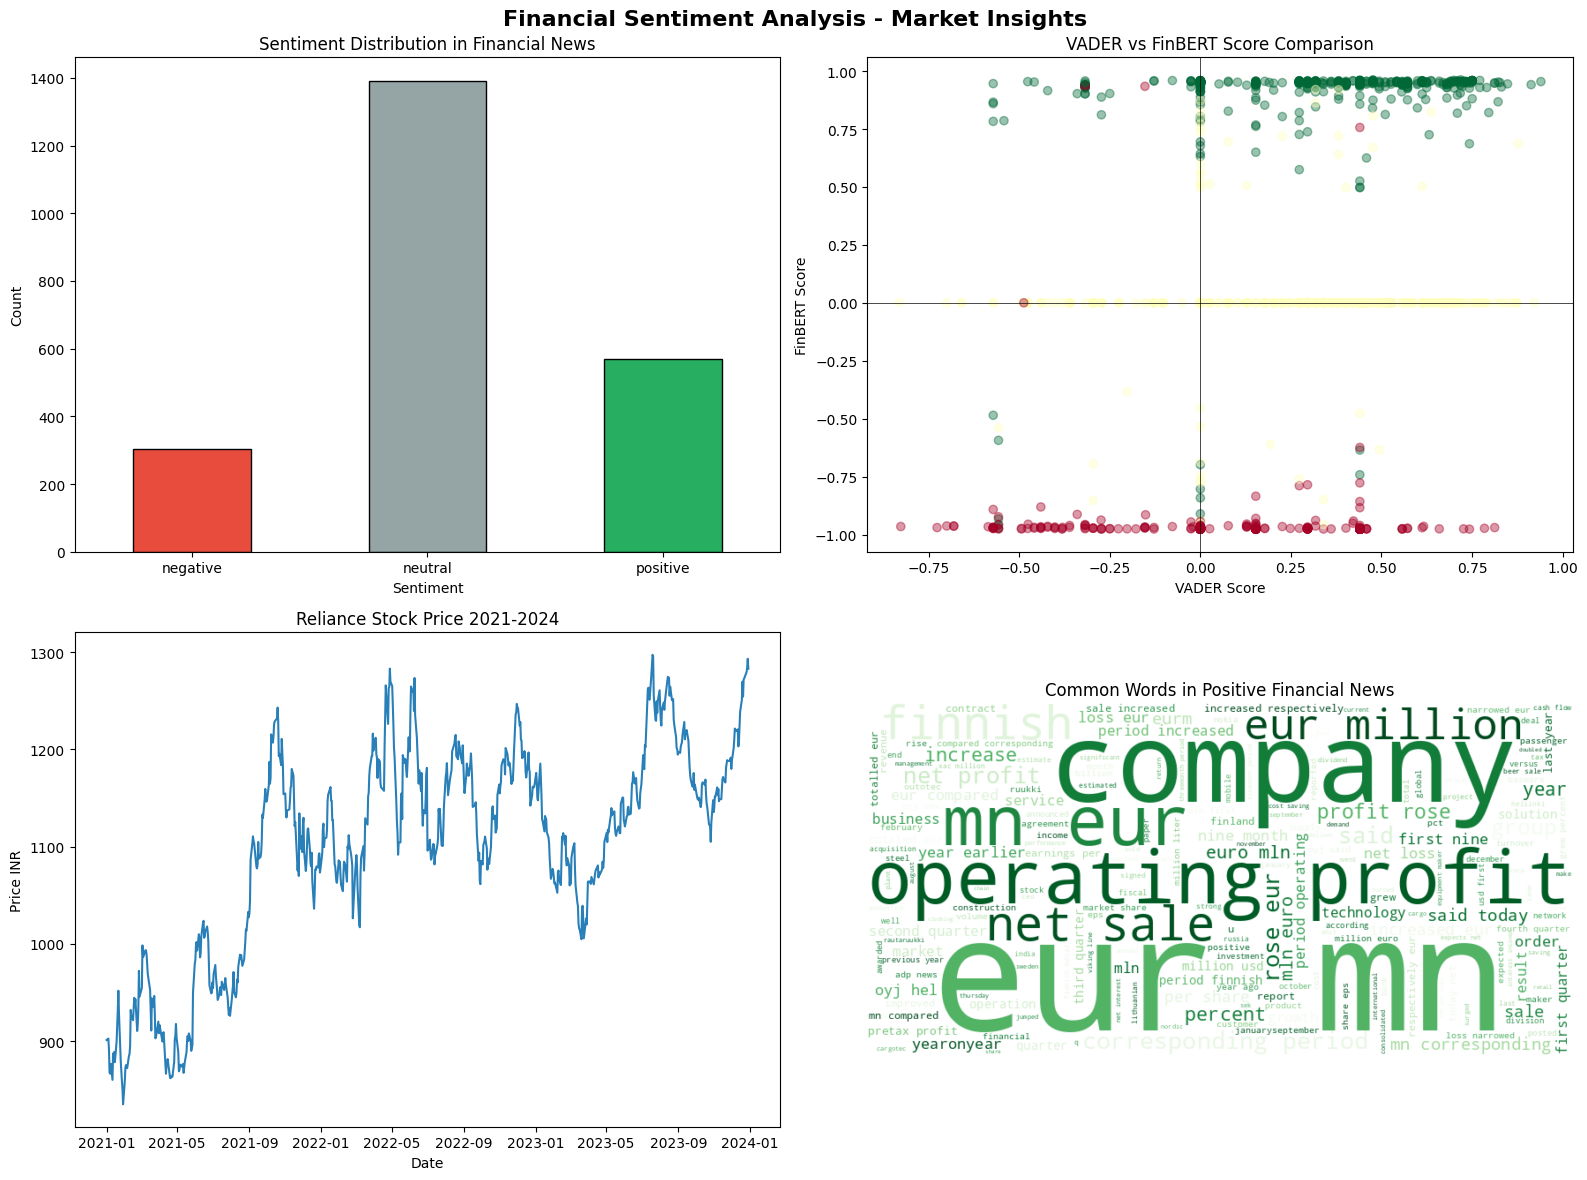

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fig.suptitle(
    "Financial Sentiment Analysis - Market Insights",
    fontsize=16,
    fontweight="bold"
)

# 1. Sentiment distribution
sentiment_counts = df["label"].value_counts().reindex(
    ["negative", "neutral", "positive"]
)

sentiment_counts.plot(
    kind="bar",
    ax=axes[0, 0],
    color=["#e74c3c", "#95a5a6", "#27ae60"],
    edgecolor="black"
)

axes[0, 0].set_title("Sentiment Distribution in Financial News")
axes[0, 0].set_xlabel("Sentiment")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=0)

# 2. VADER vs FinBERT score scatter
color_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

axes[0, 1].scatter(
    df["vader_score"],
    df["finbert_score"],
    c=df["label"].map(color_map),
    alpha=0.4,
    cmap="RdYlGn"
)

axes[0, 1].set_xlabel("VADER Score")
axes[0, 1].set_ylabel("FinBERT Score")
axes[0, 1].set_title("VADER vs FinBERT Score Comparison")
axes[0, 1].axhline(0, color="black", linewidth=0.5)
axes[0, 1].axvline(0, color="black", linewidth=0.5)

# 3. Reliance stock price
axes[1, 0].plot(
    stock_data["RELIANCE.NS"].index,
    stock_data["RELIANCE.NS"]["Close"],
    color="#2980b9"
)

axes[1, 0].set_title("Reliance Stock Price 2021-2024")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Price INR")

# 4. Word cloud for positive financial news
positive_text = " ".join(df[df["label"] == "positive"]["cleaned"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Greens"
).generate(positive_text)

axes[1, 1].imshow(wordcloud, interpolation="bilinear")
axes[1, 1].axis("off")
axes[1, 1].set_title("Common Words in Positive Financial News")

plt.tight_layout()
plt.savefig("financial_sentiment_insights.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
final_columns = [
    "text",
    "label",
    "cleaned",
    "vader_label",
    "vader_score",
    "finbert_label",
    "finbert_confidence",
    "finbert_score"
]

df[final_columns].to_csv(
    "financial_sentiment_results.csv",
    index=False
)

print("Saved file: financial_sentiment_results.csv")

Saved file: financial_sentiment_results.csv


In [17]:
vader_accuracy = accuracy_score(df["label"], df["vader_label"])
finbert_accuracy = accuracy_score(df["label"], df["finbert_label"])

print("PROJECT SUMMARY")
print("----------------")
print(f"Dataset size: {df.shape[0]} financial sentences")
print(f"VADER accuracy: {vader_accuracy:.4f}")
print(f"FinBERT accuracy: {finbert_accuracy:.4f}")
print(f"Pearson correlation with next-day Nifty return: {corr:.4f}")
print(f"P-value: {p_value:.4f}")

print("\nConclusion:")
print(
    "FinBERT performed much better than VADER because it understands financial context, "
    "while VADER relies mainly on word-level sentiment rules."
)

print("\nLimitation:")
print(
    "The sentiment-price correlation is a demonstration because the dataset does not contain dates. "
    "A production version should use dated financial news headlines matched with stock market data."
)

PROJECT SUMMARY
----------------
Dataset size: 2264 financial sentences
VADER accuracy: 0.5782
FinBERT accuracy: 0.9717
Pearson correlation with next-day Nifty return: 0.0414
P-value: 0.2607

Conclusion:
FinBERT performed much better than VADER because it understands financial context, while VADER relies mainly on word-level sentiment rules.

Limitation:
The sentiment-price correlation is a demonstration because the dataset does not contain dates. A production version should use dated financial news headlines matched with stock market data.


In [18]:
readme_text = f"""
# Financial Sentiment Analysis using FinBERT

This project compares traditional rule-based sentiment analysis using VADER with transformer-based sentiment analysis using FinBERT on financial news text.

## Dataset

The project uses the Financial PhraseBank dataset, specifically the `Sentences_AllAgree` subset.

This subset contains financial news sentences where all annotators agreed on the sentiment label.

Dataset size: {df.shape[0]} sentences

## Models Used

### VADER

VADER is a rule-based sentiment analysis model. It uses a dictionary of positive and negative words to calculate sentiment.

### FinBERT

FinBERT is a transformer model based on BERT and trained on financial text. It understands financial context better than simple word-based methods.

## Results

| Model | Accuracy |
|---|---:|
| VADER | {vader_accuracy:.4f} |
| FinBERT | {finbert_accuracy:.4f} |

FinBERT performed much better than VADER on financial sentiment classification.

## Sentiment vs Stock Return

The project also demonstrates how sentiment scores can be compared with next-day Nifty 50 returns.

Pearson correlation: {corr:.4f}

P-value: {p_value:.4f}

The correlation result is only a demonstration because the Financial PhraseBank dataset does not include dates.

## Key Learning

FinBERT is better than VADER for financial text because it understands context.

Example:

"The company avoided losses."

VADER may treat this as negative because of the word "losses", but FinBERT can understand that "avoided losses" is actually positive.

## Limitations

The dataset contains labelled financial sentences but does not contain dates.

In a production system, dated financial news headlines should be collected from a news API and matched with stock price data.

## Files

- `financial_sentiment_analysis.ipynb` - main notebook
- `financial_sentiment_results.csv` - model predictions and scores
- `model_comparison.png` - confusion matrix comparison
- `financial_sentiment_insights.png` - final visual dashboard
"""

with open("README.md", "w") as file:
    file.write(readme_text)

print("README.md created successfully")

README.md created successfully


In [19]:
import zipfile
from google.colab import files

project_files = [
    "README.md",
    "financial_sentiment_results.csv",
    "model_comparison.png",
    "financial_sentiment_insights.png"
]

zip_name = "financial_sentiment_project_files.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    for file in project_files:
        zipf.write(file)

files.download(zip_name)

print("Downloaded:", zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: financial_sentiment_project_files.zip
